# Classification

## Setup

In [1]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

## Load Data

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
X, y = mnist["data"], mnist["target"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
)

## KNeighborsClassifier

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, stratify=y, random_state=42
)

In [ ]:
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index() * 100
test_dist  = pd.Series(y_test).value_counts(normalize=True).sort_index() * 100

df = pd.DataFrame({
    "train %": train_dist.round(2),
    "test %":  test_dist.round(2)
})

print(df)

       train %  test %
class                 
0         9.86    9.86
1        11.25   11.25
2         9.98    9.99
3        10.20   10.20
4         9.75    9.75
5         9.02    9.02
6         9.82    9.82
7        10.42   10.42
8         9.75    9.75
9         9.94    9.94


In [7]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    # Note : quantization does not speed up much kNN, PCA does
    # ("pca", PCA(svd_solver="full")),
    ("knn", KNeighborsClassifier(algorithm="brute", n_jobs=1))
])

In [8]:
param_dist = {
    # "pca__n_components": st.uniform(0.90, 0.10),   # sample between 0.90–1.00 variance
    "knn__n_neighbors": st.randint(50, 150),        # sample 3–9 neighbors
    "knn__weights": ["uniform", "distance"],
    "knn__p": [2],                                # could add 1 if you want Manhattan too
}

rs = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=20,          # try 8–20 depending on time
    cv=3,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42,
    verbose=1
)
rs.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('knn',
                                              KNeighborsClassifier(algorithm='brute',
                                                                   n_jobs=1))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'knn__n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ecf738ed730>,
                                        'knn__p': [2],
                                        'knn__weights': ['uniform',
                                                         'distance']},
                   random_state=42, scoring='accuracy', verbose=1)

In [9]:
print("Best params:", rs.best_params_)
print("CV best score:", rs.best_score_)
print("Test acc:", rs.score(X_test, y_test))

Best params: {'knn__n_neighbors': 4, 'knn__p': 2, 'knn__weights': 'distance'}
CV best score: 0.9455166666666667
Test acc: 0.9498


In [10]:
rs.cv_results_

{'mean_fit_time': array([1.56370894, 1.66914781, 1.42868352, 1.37484376, 1.78689305,
        1.25637595, 1.21142085, 1.77233871, 1.39253807, 1.19674222,
        1.20758041, 1.73950179, 1.26977452, 1.20590536, 1.68697604,
        1.25179784, 1.18783689, 1.29461694, 1.61644689, 1.20425924]),
 'std_fit_time': array([0.12755556, 0.10869226, 0.0529383 , 0.00821539, 0.30555282,
        0.07899945, 0.00303784, 0.18870457, 0.2875988 , 0.01582949,
        0.00047619, 0.3942028 , 0.09466096, 0.01000132, 0.35982468,
        0.05703181, 0.00658108, 0.13174401, 0.25758529, 0.02672053]),
 'mean_score_time': array([100.44606233,  98.52104926,  98.29919481,  98.16801214,
         98.40815568,  98.53815873,  99.31719406,  97.27934027,
         98.18726937,  97.75432714,  98.58960756,  98.2062161 ,
         98.30184984,  98.46201952,  98.65227763,  97.62763786,
         98.22246305,  98.6389668 ,  98.74634965,  98.0417215 ]),
 'std_score_time': array([0.75514624, 0.3573965 , 0.04358097, 0.20261495, 0.48

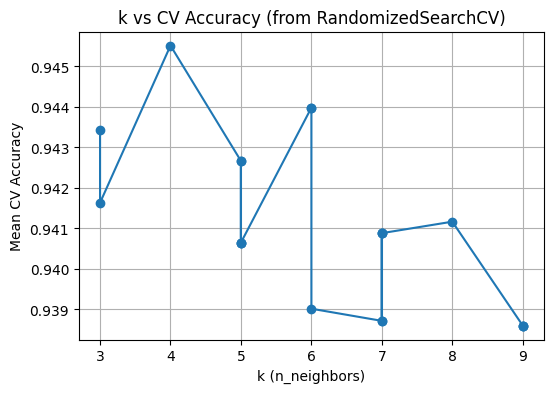

    param_knn__n_neighbors  mean_test_score
13                       3         0.943433
16                       3         0.941633
14                       4         0.945517
2                        5         0.942667
6                        5         0.940650
8                        5         0.942667
17                       5         0.940650
5                        5         0.940650
10                       6         0.943983
19                       6         0.943983
12                       6         0.939017
1                        7         0.938717
15                       7         0.940883
9                        7         0.940883
3                        7         0.938717
7                        7         0.940883
11                       8         0.941167
4                        9         0.938600
0                        9         0.938600
18                       9         0.938600


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Get CV results into a DataFrame
df = pd.DataFrame(rs.cv_results_)

# Extract relevant columns
df_plot = df[["param_knn__n_neighbors", "mean_test_score"]].copy()

# Convert param column to int (sometimes it's string/object)
df_plot["param_knn__n_neighbors"] = df_plot["param_knn__n_neighbors"].astype(int)

# Sort so the plot looks nice
df_plot = df_plot.sort_values("param_knn__n_neighbors")

# Plot
plt.figure(figsize=(6,4))
plt.plot(df_plot["param_knn__n_neighbors"], df_plot["mean_test_score"], marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Accuracy")
plt.title("k vs CV Accuracy (from RandomizedSearchCV)")
plt.grid(True)
plt.show()

print(df_plot)


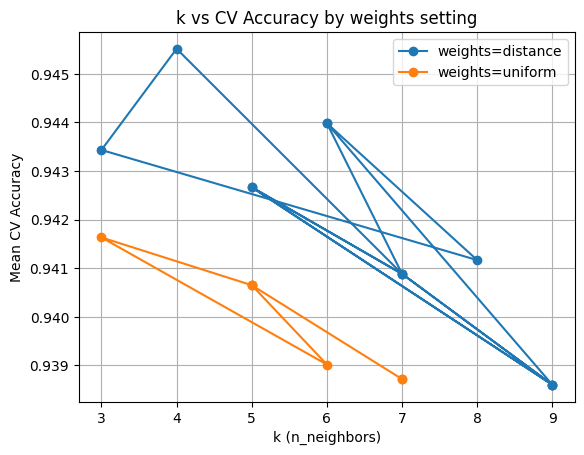

In [12]:
for w, sub in df.groupby("param_knn__weights"):
    plt.plot(sub["param_knn__n_neighbors"].astype(int),
             sub["mean_test_score"],
             marker="o",
             label=f"weights={w}")

plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Accuracy")
plt.title("k vs CV Accuracy by weights setting")
plt.legend()
plt.grid(True)
plt.show()


Another try

In [13]:
param_dist = {
    "knn__n_neighbors": st.randint(50, 150),
    "knn__weights": ["distance"],
    "knn__p": [2],
}

rs = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42,
    verbose=1
)
rs.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('knn',
                                              KNeighborsClassifier(algorithm='brute',
                                                                   n_jobs=1))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'knn__n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ecf72578b90>,
                                        'knn__p': [2],
                                        'knn__weights': ['distance']},
                   random_state=42, scoring='accuracy', verbose=1)

In [ ]:
print("Best params:", rs.best_params_)
print("CV best score:", rs.best_score_)
print("Test acc:", rs.score(X_test, y_test))

Best params: {'knn__n_neighbors': 51, 'knn__p': 2, 'knn__weights': 'distance'}
CV best score: 0.9148833333333334


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get CV results into a DataFrame
df = pd.DataFrame(rs.cv_results_)

# Extract relevant columns
df_plot = df[["param_knn__n_neighbors", "mean_test_score"]].copy()

# Convert param column to int (sometimes it's string/object)
df_plot["param_knn__n_neighbors"] = df_plot["param_knn__n_neighbors"].astype(int)

# Sort so the plot looks nice
df_plot = df_plot.sort_values("param_knn__n_neighbors")

# Plot
plt.figure(figsize=(6,4))
plt.plot(df_plot["param_knn__n_neighbors"], df_plot["mean_test_score"], marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Accuracy")
plt.title("k vs CV Accuracy (from RandomizedSearchCV)")
plt.grid(True)
plt.show()

print(df_plot)
